# Day 1 - Quantum Error Correction Technique: 3-Qubit Bit Flip Code
Today We behind with one of the simplest and most important quantum error correction codes: **3 -Qubit Bit Flip Code**
The purpose of this notebook is not just to make a qiskit circuit to work .we will understand the complete idea from mathematical level to the circuit level .By the end of this notebook we should understands :

- Why Quantum Error correction is needed
- What a quantum bit flip error is ?
- The Pauli X- Operators
- Why an quantum arbitary state cannot simply be copied
- How 3- Qubit repition code will be work 
- How an arbitary logical qubit is encoded
- How bit flip error affect te encoded state
- What a syndrom is?
- Why we use stabilzers
- How syndrom extraction works
- How the error is identified
- How recovery is performed 
- Qiskit impementation of Bit flip code

## What is Quantum Error Correction ?
The quantum computer does not operated in perfectly isolated environment. Physical qubits intract with their environment  and are affected by imperfection 
in quantum gates,control electronics ,measurememt devices ,and other physical processes. this effect introdue **errors** into quantum information.some important quantum errors are :
- bit flip error
- phase flip error
- Bit and Phase errors
- Depolarizing errors
- Amplitude damping 
- measurement errors

Today we will focus on simplest one :
A bit Flip changes: $|0\rangle \rightarrow |1\rangle$  and  $|1\rangle \rightarrow |0\rangle$
In quantum mechanic this operation is represented by the Puali-X matrix.

### Why Error Correction is Necessary?
Imagine that we have a quantum state:  $|\psi\rangle = \alpha |0\rangle + \beta |1\rangle$

Using Linearity : $|\psi\rangle = \alpha  X|0\rangle + \beta X|1\rangle$

Since : $ X|0\rangle = X|1\rangle$ and $X|1\rangle = X|0\rangle$

We Obtained : $X|\psi\rangle = \alpha |0\rangle + \beta |1\rangle$

Therefore the quantum information has changed ,if we do nothing error become the part of computation.this is why a quantum computer needs a mechanism for detecting  and correcting errors.

## Import Required Libraries
Import NumPy for numerical calculation,Matplotlib for visualization and AerSimulator for local simulation.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

## Step 1 : Create Three Physical Qubit 
The 3-Qubit bit flip code uses three physical qubits. we will call them : q0,q1,q2
for now we will only createquantum circuit.No classical bit requied yet because we are first learning the encoding circuit.

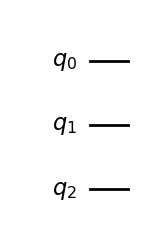

In [2]:
qc=QuantumCircuit(3)
qc.draw("mpl")

## Step 2 : Initilize the Logical Qubit
Our logical information start in qubit q0.for a simple demonstration ,we will prepare :$|\psi\rangle = \alpha |0\rangle + \beta |1\rangle$

Using Ry() Gate the rotation Ry(theta) creates $\cos(\theta/2)|0\rangle>  + \sin(\theta/2)|1\rangle$ .we use this always starting with |0> because we want to demonstartion that the QEC circuit works with a general superposition.
for here ,
Apply Ry rotation on qubit 0 ,with theta= $\pi$/3
This state  becomes : $\cos(\pi/6)|0\rangle>  + \sin(\pi/6)|1\rangle$ or $\sqrt{3}/2|0\rangle  + 1/2|1\rangle$
we now have one logical qubit stored in q0 and other two qubit are still in : $|0\rangle$ so total state become **$|\psi\rangle|00\rangle$**

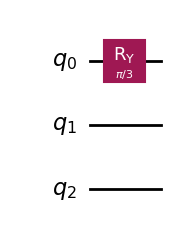

In [3]:
theta =np.pi /3
qc.ry(theta,0)
qc.draw("mpl")

## Step 3 : Encoded the Logical Qubit
the 3-Qubit Bit flip code uses $|0\rangle \rightarrow |000\rangle$ and $|1\rangle \rightarrow |111\rangle$. 
therefore, state $\alpha|0\rangle +\beta|1\rangle$ become $\alpha|000\rangle +\beta|111\rangle$

so we will implement this using the CNOT Gate .CNOT Gate create the required entangled code state.

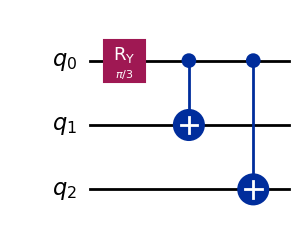

In [5]:
#encoding
qc.cx(0,1)
qc.cx(0,2)
qc.draw("mpl")

## Step 4 : Inspect Encoded State
Before introducing the error ,let's inspect the statevector ,This is useful during developement because it let us verify that our encoding circuit produces the state we expected.

In [6]:
from qiskit.quantum_info import Statevector
state=Statevector.from_instruction(qc)
print(state)

Statevector([0.8660254+0.j, 0.       +0.j, 0.       +0.j, 0.       +0.j,
             0.       +0.j, 0.       +0.j, 0.       +0.j, 0.5      +0.j],
            dims=(2, 2, 2))


## Step 5 : Display Non-Zero Amplitudes
Instead of printing the complete statevector ,we can display only the basis state that have non-zero amplitude. for non-zero state we expect conribution from
|000 > and |111>.

In [7]:
for index,amplitude in enumerate(state.data):
    if abs(amplitude)>1e-10:
        bitstring=format(index,"03b")
        print(
            f"|{bitstring}> :"
            f"{amplitude.real:.6f}"
            f"+{amplitude.imag:.6f}i"
        )

|000> :0.866025+0.000000i
|111> :0.500000+0.000000i


## Step 5 : Introducing The Error
Now we simulate the physical error that our code is designed to correct.In qiskit a bit flip is simply: X  so qc.x(1) mean apply Pauli X-Gate to physical qubit 1. Mathematically $ X1=0 $  we delibartly insert this gate after encoding to simulate a physical error.here the order is imporatant :
$prepare \rightarrow Encode\rightarrow Error$ the error is placed after encoding because we want to model an error ocuring on one of the physical qubit . if we would simply the changing the logical input before the error correction procedure .for QEC experiment  we normally want simulate :
Logical information -> encoded physical information -> physical noise


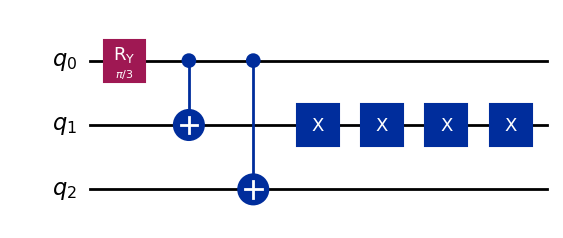

In [12]:
#simulate bit flip error on q1
qc.x(1)
qc.draw("mpl")


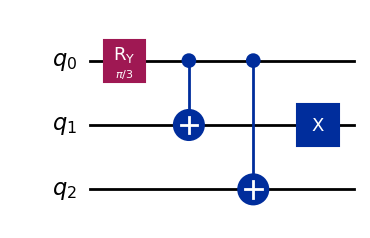

In [15]:
qc.data.pop()
qc.draw("mpl")

## Step 6: Add Syndrome Ancillas
To detect the error without directly measuring the qubit ,we introduced tqo ancilla qubits,out circuit now contains:
- Data qubit : q0,q1,q2
- Ancilla qubits : a0,a1

Ancilla qubit store parity information,we will use :
- a0 -> parity of q0 and q1
- a1 -> parity of q1 and q2

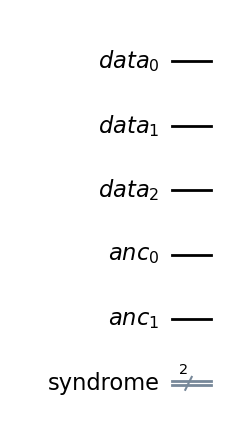

In [17]:
from qiskit import QuantumRegister,ClassicalRegister
data= QuantumRegister(3,"data")
anc=QuantumRegister(2,"anc")
syndrom=ClassicalRegister(2,"syndrome")
qc=QuantumCircuit(
    data,
    anc,
    syndrom
)
qc.draw("mpl")

## Step 7 :Build the complete Encoding+Error Circuit
we now combine :
1. Logical state preparation
2. Encoding
3. Bit-flip Error
we will keep these opeartion together so that later syndrome circuit is easier to understand.


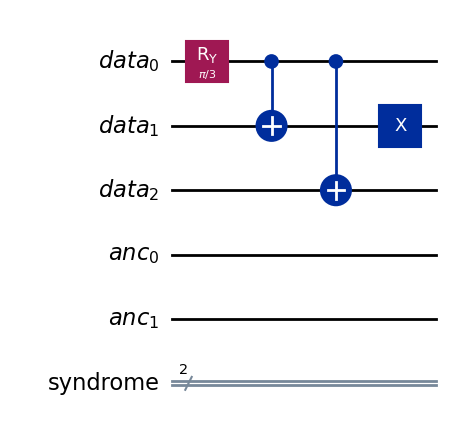

In [18]:
#Prepare logical state
qc.ry(theta,data[0])
#Encode
qc.cx(data[0],data[1])
qc.cx(data[0],data[2])
#introduces X error on q1
qc.x(data[1])
qc.draw("mpl")

### First Syndrom check :q0 and q1
we want to determine whether q0 and q1 have the same compuational basis value.we use ancilla a0. 

1.initially a0= |0> 

2.we apply CX(q0-> a0)

3.apply CX(q1-> a0)
the ancilla store the parity of q0 and q1 :
- a0=0 then they are equal
- a0=1 then they are different 

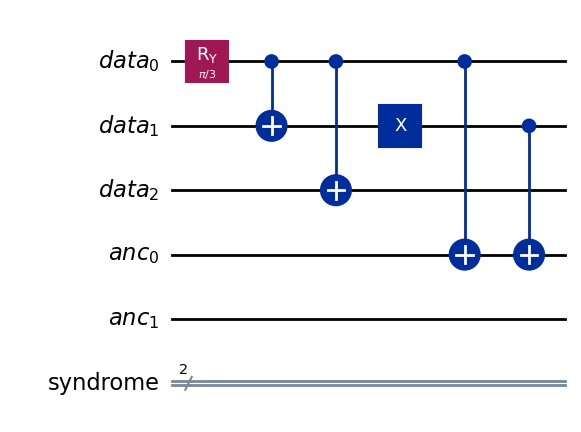

In [19]:
# Syndrom s1=parity(q0,q1)
qc.cx(data[0],anc[0])
qc.cx(data[1],anc[0])
qc.draw("mpl")

### Second Syndrome check :q1 and q2
we want to determine whether q1 and q2 have the same compuational basis value.we use ancilla a1. 

1.initially a1= |0> 

2.we apply CX(q1-> a1)

3.apply CX(q2-> a2)
the ancilla store the parity of q0 and q1 :
- a1=0 then they are equal
- a1=1 then they are different 

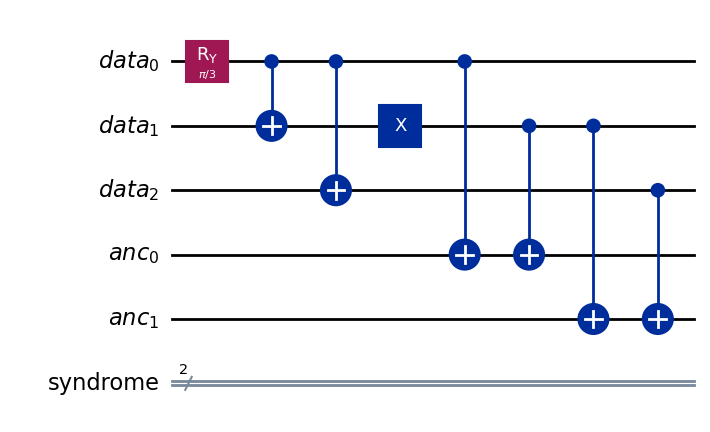

In [20]:
# Syndrom S2 =parity(q1,q2)
qc.cx(data[1],anc[1])
qc.cx(data[2],anc[1])
qc.draw("mpl")

## Step 8 :Measure the ancillas
the two ancillas now contains the syndrom information. we measure:
- a0 -> syndrome[0]
- a1 -> Syndrome[1]

The data qubits are not measured ,this is important we want to preserve the quantum information stored in data block.

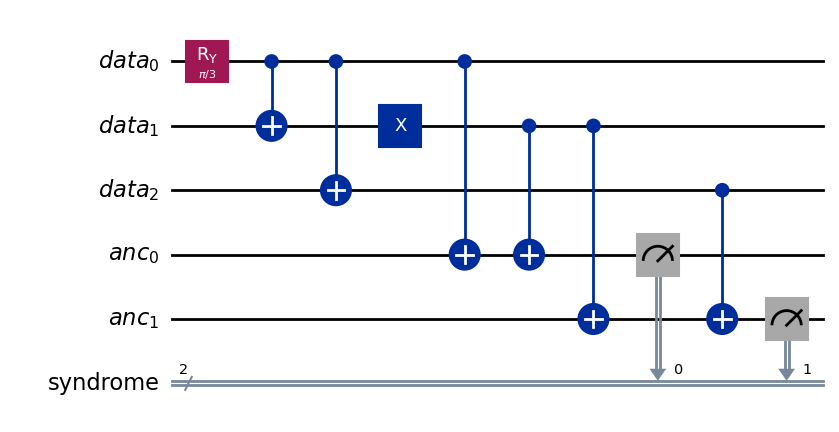

In [21]:
qc.measure(anc[0],syndrom[0])
qc.measure(anc[1],syndrom[1])
qc.draw("mpl")

## Step 8 : Run the Syndrome Circuit
We now execute the circuit on the local simulator .we use 1024 shots,becuase we are using an ideal simulator and delibratly introduced a deterministic error we expect one dominant syndrom. for an X error on q1 ,the expected syndrom is : 11 
The Syndrom is classical information that tells the decoder which physical qubit should be corrected.
The reason is:
- q0 and q1 are different -> first syndrome bit =1
- q1 and q2 are diffrent ->second syndrome bit =1

therefore,11 -> X error on q1 our decoder can now determine which recovery operation to apply.

In [22]:
result=AerSimulator().run(qc,shots=1024).result()
counts=result.get_counts()
print(counts)

{'11': 1024}


## Step 9 : Recovery
for Syndrome '11' the  decoder identifies q1.therefore we apply :
X(q1)
since : X*X =I

the recovery  X cancels the original X error.In a complete QEC system,this X gate would be applied  conditionally according to measured syndrome.

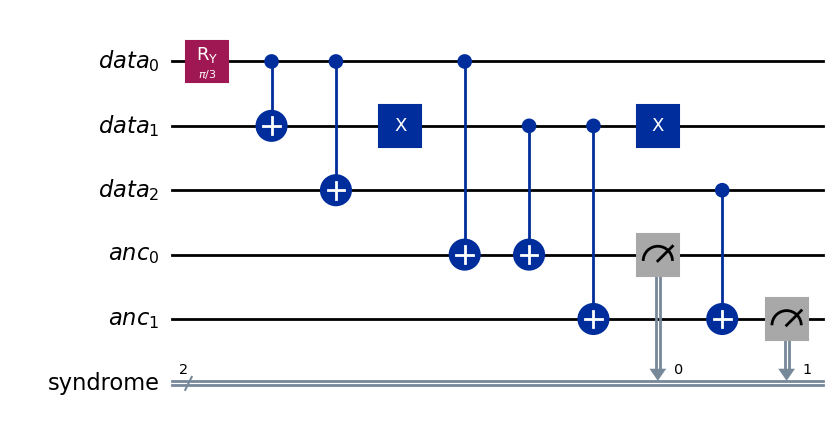

In [23]:
qc.x(data[1])
qc.draw("mpl")

## Step 10 : Decode

the encoding used:
CX(q0,q1) and CX(q0,q2)

to reverse it,apply the gate in reverse order:
CX(q0,q2) and CX(q0,q1)

CNOT is its own inverse ,so these gates restore the original logical qubit to q0.

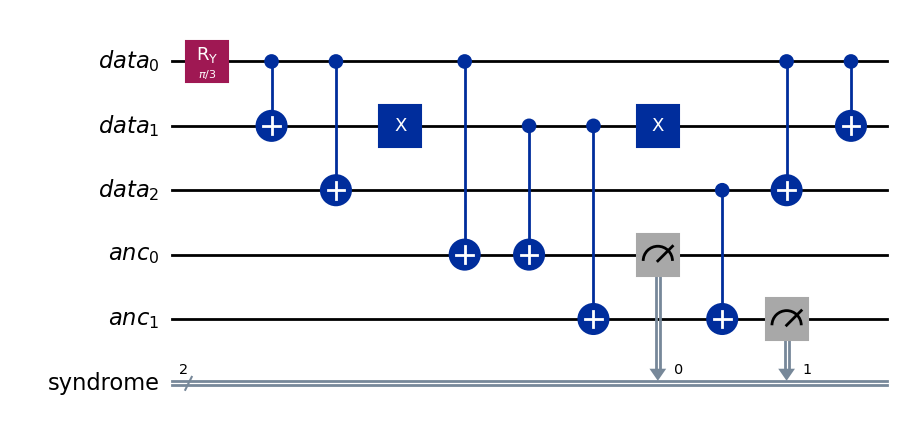

In [24]:
qc.cx(data[0],data[2])
qc.cx(data[0],data[1])
qc.draw("mpl")

## Test All single Qubit Errors
the code should identify all three possible single bit-flip errors. Expected syndrome table:

- X on q1 -> 10
- X on q1 ->11
- X on q2 -> 01
- No error ->00

Try changing qc.x(data[1]) to qc.x(data[0]) and qc.x(data[2])
 and compare measured syndrome.

In [26]:
def syndrome_test(error_qubit=None):
    data=QuantumRegister(3,"data")
    anc=QuantumRegister(2,"anc")
    syndrome=ClassicalRegister(2,"syndrome")
    circuit=QuantumCircuit(data,anc,syndrome)

    #Encode
    circuit.ry(theta,data[0])
    circuit.cx(data[0],data[1])
    circuit.cx(data[0],data[2])

    #Error
    if error_qubit is not None:
        circuit.x(data[error_qubit])

    #Syndrome extraction
    circuit.cx(data[0],anc[0])
    circuit.cx(data[1],anc[0])
    circuit.cx(data[1],anc[1])
    circuit.cx(data[2],anc[1])

    #Measure Syndrome
    circuit.measure(anc[0],syndrome[0])
    circuit.measure(anc[1],syndrome[1])

    #run syndrome circuir
    result=AerSimulator().run(circuit,shots=1024).result()

    return result.get_counts()

for error in [None ,0,1,2]:
    print(f"Error q{error}: {syndrome_test(error)}")


Error qNone: {'00': 1024}
Error q0: {'01': 1024}
Error q1: {'11': 1024}
Error q2: {'10': 1024}


here look at result above. each syndrome apperas 1024/1024 times becuase the simulation is ideal ad deterministics.this confirms that 3-qubit bit flip code can detect the location of any single bit flip error.


## Visualization
the simulation produce a unique syndrome for each single qubit bit flip error, with 100%  probability in the ideal simulator.this confirms that -qubit bit-flip code can identify the location of a single X error .

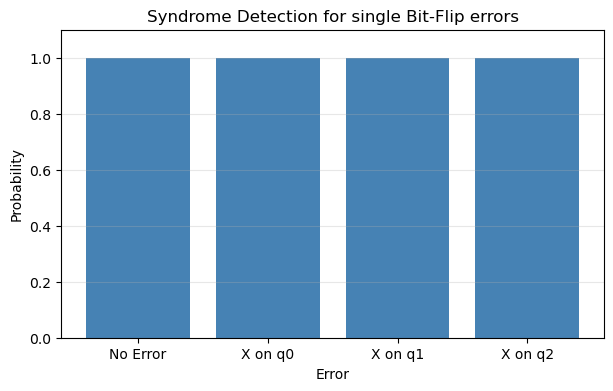

In [28]:
errors=["No Error","X on q0","X on q1","X on q2"]
syndroms=["00","10","11","01"]
probabilities=[]
for error in[None,0,1,2]:
    counts=syndrome_test(error)
    syndrome=max(counts,key=counts.get)
    probabilities.append(counts[syndrome]/1024)
plt.figure(figsize=(7,4))
plt.bar(errors,probabilities,color="steelblue")
plt.ylabel("Probability")
plt.xlabel("Error")
plt.title("Syndrome Detection for single Bit-Flip errors")
plt.ylim(0,1.1)
plt.grid(axis="y",alpha=0.3)
plt.show()

--

**Author:** *Shreya Palase*  

**Date Created:**  *3-sep-2026*

**project:** Quantum-Error-Correction-Techniques

**File:** Day1-3Qubit_Bit_Flip_Code.ipynb

Thank you and Keep Learning!

<sub>© Shreya Palase- All Rights Reserved.This notbook is part of a structured learning series designed for Github publication.</sub>